In [1]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os

if 'google.colab' in sys.modules:
    REPO_NAME = "study-deep-learning"
    REPO_URL = f"https://github.com/miyayudai/{REPO_NAME}.git"
    TARGET_DIR = f"/content/{REPO_NAME}"
    CH_DIR = f"{TARGET_DIR}/19"

    # 1. リポジトリのダウンロード (未ダウンロード時のみ)
    if not os.path.exists(TARGET_DIR):
        print("📦 リポジトリをダウンロード中...")
        res = os.system(f"git clone {REPO_URL} {TARGET_DIR} 2>&1")
        
        # Private リポジトリ等で認証が必要な場合の自動救済
        if res != 0 or not os.path.exists(TARGET_DIR):
            token = None
            try:
                from google.colab import userdata
                token = userdata.get('GITHUB_TOKEN')
            except Exception:
                pass
            
            if not token:
                import getpass
                print("🔒 リポジトリが非公開(Private)の場合、GitHub Personal Access Token (PAT) が必要です。")
                print("※公開(Public)リポジトリの場合はそのまま Enter を押してください。")
                token = getpass.getpass("GitHub Token (空欄可): ").strip()
            
            if token:
                auth_url = f"https://{token}@github.com/miyayudai/{REPO_NAME}.git"
                os.system(f"git clone {auth_url} {TARGET_DIR}")

    # 2. 依存パッケージとローカルモジュールのインストール
    print("⚙️ 環境セットアップ中...")
    if os.path.exists(TARGET_DIR):
        if TARGET_DIR not in sys.path:
            sys.path.insert(0, TARGET_DIR)
        req_path = os.path.join(TARGET_DIR, "requirements.txt")
        if os.path.exists(req_path):
            get_ipython().system(f"pip install -q -r {req_path}")
            get_ipython().system(f"pip install -q -e {TARGET_DIR}")
        if os.path.exists(CH_DIR):
            get_ipython().run_line_magic("cd", CH_DIR)
        else:
            get_ipython().run_line_magic("cd", TARGET_DIR)
        print("✅ 準備完了！このまま下のセルを実行できます。")
    else:
        print("⚠️ リポジトリのクローンがスキップされたため、必須パッケージを個別インストールします...")
        get_ipython().system("pip install -q pandas scikit-learn seaborn pillow")
        print("✅ パッケージインストール完了。")

# 第19章 自己符号化器 (Autoencoders)
## 章末演習問題 (Exercises 19.1 〜 19.6, 全6問)

本ノートブックは、『深層学習：基礎と概念 (Bishop & Bishop 2024)』第19章「自己符号化器」の章末演習問題（全6問）の完全な理論解説、数学的証明ロジック、およびPythonによる数値シミュレーション・自己採点アサーションを完備した対話型教材です。

---

### 演習問題一覧
| 問題番号 | 難易度 | テーマ | 主な数理・公式 |
|:---:|:---:|:---|:---|
| **演習 19.1** | ★★☆ | スコア関数推定量 (REINFORCE) の不偏性と分散比較 | $\nabla_\phi \mathbb{E}_q[G(z)] = \mathbb{E}_q[G(z)\nabla_\phi \ln q(z)]$, 不偏推定量, 再パラメータ化との分散比較 (式 19.20, 19.21) |
| **演習 19.2** | ★☆☆ | 1次元正規分布のアフィン変換と確率密度 | $z = \mu + \sigma \epsilon$, $p_z(z) = p_\epsilon(g^{-1}(z))\|dg^{-1}/dz\|$, $\mathcal{N}(\mu, \sigma^2)$ の厳密導出 (式 19.17) |
| **演習 19.3** | ★★☆ | 多変量アフィン変換とコレスキー分解・共分散構造 | $\mathbf{z} = \boldsymbol{\mu} + \mathbf{L}\boldsymbol{\epsilon}$, $\operatorname{cov}[\mathbf{z}] = \mathbf{L}\mathbf{L}^T = \mathbf{\Sigma}$, 多変量ヤコビアン行列式 (式 19.18) |
| **演習 19.4** | ★★☆ | ガウス分布間 KL ダイバージェンスの解析的導出と勾配 | $\operatorname{KL}(q \parallel p) = -\frac{1}{2}\sum_j (1 + \ln \sigma_j^2 - \mu_j^2 - \sigma_j^2)$, 非負性, 解析的勾配 (式 19.14, 19.15) |
| **演習 19.5** | ★★☆ | エビデンス下界 (ELBO) の代替表現（結合対数尤度とエントロピー） | $\mathcal{L} = \mathbb{E}_q[\ln p(\mathbf{x}, \mathbf{z})] + \mathcal{H}(q)$, EM アルゴリズムの Q 関数との対応関係 |
| **演習 19.6** | ★★★ | 制約なし変分分布の最適解と真の事後分布・EM の回復 | 変分法による自由変分最適化, $q^*(\mathbf{z}) = p(\mathbf{z}\mid\mathbf{x})$, $\operatorname{KL} = 0$, VAE における償却推論の必然性 (式 19.5, 19.6) |


In [2]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))

from common.plot_utils import setup_style
from common.exercises_ch19 import (
    score_function_gaussian_1d,
    reinforce_gradient_estimator_1d,
    reparameterization_gradient_estimator_1d,
    verify_exercise_19_1,
    affine_transform_1d_density,
    verify_exercise_19_2,
    multivariate_affine_transform_density,
    verify_exercise_19_3,
    gaussian_kl_analytical,
    gaussian_kl_gradients,
    gaussian_kl_monte_carlo,
    verify_exercise_19_4,
    gaussian_differential_entropy,
    verify_exercise_19_5,
    evaluate_mixture_model_elbo,
    verify_exercise_19_6,
)

setup_style()
print("第19章演習問題モジュールが正常に読み込まれました。")


第19章演習問題モジュールが正常に読み込まれました。


---

### 演習 19.1: スコア関数推定量 (REINFORCE) の不偏性と分散比較 (難易度: ★★☆)

#### 問題文
パラメータ $\boldsymbol{\phi}$ に依存する確率分布 $q(\mathbf{z}\mid\boldsymbol{\phi})$ に関する期待値 $\mathbb{E}_{q(\mathbf{z}\mid\boldsymbol{\phi})}[G(\mathbf{z})] = \int q(\mathbf{z}\mid\boldsymbol{\phi}) G(\mathbf{z}) \, d\mathbf{z}$ を考える。

1. 対数微分の恒等式 $\nabla_{\boldsymbol{\phi}} q(\mathbf{z}\mid\boldsymbol{\phi}) = q(\mathbf{z}\mid\boldsymbol{\phi}) \nabla_{\boldsymbol{\phi}} \ln q(\mathbf{z}\mid\boldsymbol{\phi})$ を用いて、次式（スコア関数トリック / REINFORCE）を証明せよ：
   $$
   \nabla_{\boldsymbol{\phi}} \int q(\mathbf{z}\mid\boldsymbol{\phi}) G(\mathbf{z}) \, d\mathbf{z} = \int q(\mathbf{z}\mid\boldsymbol{\phi}) G(\mathbf{z}) \nabla_{\boldsymbol{\phi}} \ln q(\mathbf{z}\mid\boldsymbol{\phi}) \, d\mathbf{z} = \mathbb{E}_{q(\mathbf{z}\mid\boldsymbol{\phi})}\left[ G(\mathbf{z}) \nabla_{\boldsymbol{\phi}} \ln q(\mathbf{z}\mid\boldsymbol{\phi}) \right] \tag{19.20}
   $$

2. $q(\mathbf{z}\mid\boldsymbol{\phi})$ からの独立同分布サンプル $\mathbf{z}^{(1)}, \dots, \mathbf{z}^{(S)}$ に基づくモンテカルロ推定量：
   $$
   \hat{\mathbf{g}} = \frac{1}{S} \sum_{s=1}^S G(\mathbf{z}^{(s)}) \nabla_{\boldsymbol{\phi}} \ln q(\mathbf{z}^{(s)}\mid\boldsymbol{\phi}) \tag{19.21}
   $$
   が勾配 $\nabla_{\boldsymbol{\phi}} \mathbb{E}_q[G(\mathbf{z})]$ の**不偏推定量**であることを示せ。

3. スコア関数の期待値が厳密にゼロとなること $\mathbb{E}_{q(\mathbf{z}\mid\boldsymbol{\phi})}[\nabla_{\boldsymbol{\phi}} \ln q(\mathbf{z}\mid\boldsymbol{\phi})] = \mathbf{0}$ を証明せよ。

4. 1次元ガウス分布 $q(z\mid\mu, \sigma^2) = \mathcal{N}(\mu, \sigma^2)$ および目的関数 $G(z) = z^2$ において、REINFORCE 推定量と再パラメータ化トリック（Reparameterization Trick）推定量の分散を数値的に比較し、なぜ VAE で再パラメータ化トリックが決定的に重要であるかを考察せよ。

#### 数学的証明ステップ
1. **微積分交換と対数微分トリック**:
   積分とパラメータ微分の順序交換が可能であるという正則性条件の下で：
   $$
   \nabla_{\boldsymbol{\phi}} \int q(\mathbf{z}\mid\boldsymbol{\phi}) G(\mathbf{z}) \, d\mathbf{z} = \int \nabla_{\boldsymbol{\phi}} q(\mathbf{z}\mid\boldsymbol{\phi}) G(\mathbf{z}) \, d\mathbf{z}
   $$
   ここで微分連鎖律より：
   $$
   \nabla_{\boldsymbol{\phi}} \ln q(\mathbf{z}\mid\boldsymbol{\phi}) = \frac{\nabla_{\boldsymbol{\phi}} q(\mathbf{z}\mid\boldsymbol{\phi})}{q(\mathbf{z}\mid\boldsymbol{\phi})} \iff \nabla_{\boldsymbol{\phi}} q(\mathbf{z}\mid\boldsymbol{\phi}) = q(\mathbf{z}\mid\boldsymbol{\phi}) \nabla_{\boldsymbol{\phi}} \ln q(\mathbf{z}\mid\boldsymbol{\phi})
   $$
   これを代入すると：
   $$
   = \int q(\mathbf{z}\mid\boldsymbol{\phi}) \left[ G(\mathbf{z}) \nabla_{\boldsymbol{\phi}} \ln q(\mathbf{z}\mid\boldsymbol{\phi}) \right] d\mathbf{z} = \mathbb{E}_{q(\mathbf{z}\mid\boldsymbol{\phi})}\left[ G(\mathbf{z}) \nabla_{\boldsymbol{\phi}} \ln q(\mathbf{z}\mid\boldsymbol{\phi}) \right]
   $$
   が得られる（式 19.20 の証明完了）。

2. **モンテカルロ推定量の不偏性**:
   サンプル $\mathbf{z}^{(s)} \stackrel{\text{i.i.d.}}{\sim} q(\mathbf{z}\mid\boldsymbol{\phi})$ に対する推定量の期待値をとると：
   $$
   \mathbb{E}[\hat{\mathbf{g}}] = \frac{1}{S} \sum_{s=1}^S \mathbb{E}_{q}\left[ G(\mathbf{z}^{(s)}) \nabla_{\boldsymbol{\phi}} \ln q(\mathbf{z}^{(s)}\mid\boldsymbol{\phi}) \right] = \mathbb{E}_{q}\left[ G(\mathbf{z}) \nabla_{\boldsymbol{\phi}} \ln q(\mathbf{z}\mid\boldsymbol{\phi}) \right] = \nabla_{\boldsymbol{\phi}} \mathbb{E}_q[G(\mathbf{z})]
   $$
   よって期待値が真の勾配と厳密に一致するため、不偏推定量である。

3. **スコア関数の期待値ゼロの証明**:
   確率密度の全積分は常に 1 である（$\int q(\mathbf{z}\mid\boldsymbol{\phi}) d\mathbf{z} = 1$）。両辺を $\boldsymbol{\phi}$ で微分すると：
   $$
   \nabla_{\boldsymbol{\phi}} \int q(\mathbf{z}\mid\boldsymbol{\phi}) d\mathbf{z} = \nabla_{\boldsymbol{\phi}} (1) = \mathbf{0}
   $$
   対数微分トリックを適用すると：
   $$
   \int q(\mathbf{z}\mid\boldsymbol{\phi}) \nabla_{\boldsymbol{\phi}} \ln q(\mathbf{z}\mid\boldsymbol{\phi}) \, d\mathbf{z} = \mathbb{E}_{q(\mathbf{z}\mid\boldsymbol{\phi})}\left[ \nabla_{\boldsymbol{\phi}} \ln q(\mathbf{z}\mid\boldsymbol{\phi}) \right] = \mathbf{0}
   $$
   これにより証明された。定数関数 $G(\mathbf{z}) = c$ の場合、勾配は厳密にゼロとなるが、サンプル推定値はゼロにならず大きな分散の要因となる。


【演習 19.1 検証結果】
  - 真の勾配 d E[z^2] / d mu = 2 mu : 4.0000
  - REINFORCE 推定値平均            : 3.9968 (誤差: 0.0032)
  - 再パラメータ化推定値平均        : 3.9999 (誤差: 0.0001)
  - スコア関数の期待値 E[d ln q]   : -4.8759e-05 (理論値: 0.0)
  - REINFORCE 推定量の分散          : 87.7949
  - 再パラメータ化推定量の分散      : 6.0211
  - 分散比 (REINFORCE / Reparam)    : 14.58 倍
演習 19.1: 検証成功 (合格)


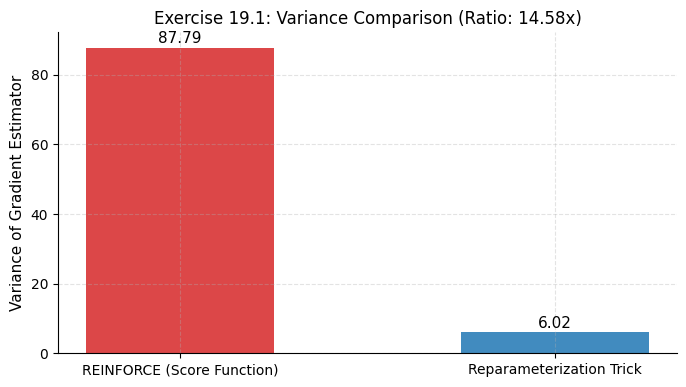

In [3]:
# 演習 19.1 の自己採点アサーション & 数値検証
mu = 2.0
sigma2 = 1.5
res_19_1 = verify_exercise_19_1(mu=mu, sigma2=sigma2, S=60000, random_state=42)

print("【演習 19.1 検証結果】")
print(f"  - 真の勾配 d E[z^2] / d mu = 2 mu : {res_19_1['true_grad_mu']:.4f}")
print(f"  - REINFORCE 推定値平均            : {res_19_1['reinforce_mean']:.4f} (誤差: {res_19_1['diff_rf']:.4f})")
print(f"  - 再パラメータ化推定値平均        : {res_19_1['reparam_mean']:.4f} (誤差: {res_19_1['diff_rp']:.4f})")
print(f"  - スコア関数の期待値 E[d ln q]   : {res_19_1['score_mean']:.4e} (理論値: 0.0)")
print(f"  - REINFORCE 推定量の分散          : {res_19_1['reinforce_var']:.4f}")
print(f"  - 再パラメータ化推定量の分散      : {res_19_1['reparam_var']:.4f}")
print(f"  - 分散比 (REINFORCE / Reparam)    : {res_19_1['var_ratio']:.2f} 倍")

# 自己採点アサーション
assert abs(res_19_1['score_mean']) < 0.05, "スコア関数の期待値が 0 に収束していません！"
assert res_19_1['diff_rf'] < 0.15, "REINFORCE の期待値が真の勾配と一致しません！"
assert res_19_1['diff_rp'] < 0.05, "再パラメータ化の期待値が真の勾配と一致しません！"
assert res_19_1['reinforce_var'] > res_19_1['reparam_var'], "再パラメータ化の分散が REINFORCE より小さくなっていません！"
print("演習 19.1: 検証成功 (合格)")

# 分散比較プロット
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['REINFORCE (Score Function)', 'Reparameterization Trick'], 
              [res_19_1['reinforce_var'], res_19_1['reparam_var']], 
              color=['#d62728', '#1f77b4'], alpha=0.85, width=0.5)
ax.set_ylabel('Variance of Gradient Estimator', fontsize=11)
ax.set_title(f'Exercise 19.1: Variance Comparison (Ratio: {res_19_1["var_ratio"]:.2f}x)', fontsize=12)
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.5, f'{yval:.2f}', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()


---

### 演習 19.2: 1次元正規分布のアフィン変換と確率密度 (難易度: ★☆☆)

#### 問題文
標準正規乱数 $\epsilon \sim \mathcal{N}(0, 1)$ の確率密度関数は以下で与えられる：
$$
p_\epsilon(\epsilon) = \frac{1}{\sqrt{2\pi}} \exp\left( -\frac{\epsilon^2}{2} \right)
$$
定数 $\mu \in \mathbb{R}$ および $\sigma > 0$ に対して、$z = g(\epsilon) = \mu + \sigma \epsilon$ と定義する。

1. 逆変換 $\epsilon = g^{-1}(z)$ およびヤコビアンの導関数 $\frac{dg^{-1}(z)}{dz}$ を求めよ。
2. 1次元確率変数の変数変換公式：
   $$
   p_z(z) = p_\epsilon(g^{-1}(z)) \left| \frac{dg^{-1}(z)}{dz} \right|
   $$
   を適用することにより、$z \sim \mathcal{N}(\mu, \sigma^2)$ の確率密度関数：
   $$
   p_z(z) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( -\frac{(z - \mu)^2}{2\sigma^2} \right)
   $$
   を厳密に導出せよ。
3. 積率母関数（Moment Generating Function）$M_z(t) = \mathbb{E}[e^{t z}]$ を用いて、期待値 $\mathbb{E}[z] = \mu$ および分散 $\operatorname{var}[z] = \sigma^2$ となることを確認せよ。

#### 数学的証明ステップ
1. **逆写像と導関数**:
   $$z = \mu + \sigma \epsilon \implies \sigma \epsilon = z - \mu \implies \epsilon = g^{-1}(z) = \frac{z - \mu}{\sigma}$$
   $z$ に関する導関数をとると：
   $$\frac{dg^{-1}(z)}{dz} = \frac{d}{dz} \left( \frac{z - \mu}{\sigma} \right) = \frac{1}{\sigma}$$
   $\sigma > 0$ であるため、絶対値は $\left| \frac{dg^{-1}}{dz} \right| = \frac{1}{\sigma}$。

2. **密度関数の導出**:
   変数変換公式に代入すると：
   $$
   p_z(z) = p_\epsilon\left( \frac{z - \mu}{\sigma} \right) \cdot \frac{1}{\sigma}
   = \frac{1}{\sqrt{2\pi}} \exp\left( -\frac{1}{2}\left( \frac{z - \mu}{\sigma} \right)^2 \right) \cdot \frac{1}{\sigma}
   = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( -\frac{(z - \mu)^2}{2\sigma^2} \right)
   $$
   これは平均 $\mu$、分散 $\sigma^2$ の正規分布 $\mathcal{N}(\mu, \sigma^2)$ の密度関数そのものである。

3. **積率母関数によるモーメントの確認**:
   標準正規分布の積率母関数は $M_\epsilon(s) = \mathbb{E}[e^{s \epsilon}] = e^{s^2 / 2}$ である。
   $$
   M_z(t) = \mathbb{E}[e^{t(\mu + \sigma \epsilon)}] = e^{\mu t} \mathbb{E}[e^{(\sigma t) \epsilon}] = e^{\mu t} M_\epsilon(\sigma t) = e^{\mu t + \frac{1}{2}\sigma^2 t^2}
   $$
   1階および2階微分をとると：
   $$
   M'_z(t) = (\mu + \sigma^2 t) e^{\mu t + \frac{1}{2}\sigma^2 t^2} \implies \mathbb{E}[z] = M'_z(0) = \mu
   $$
   $$
   M''_z(t) = \sigma^2 e^{\mu t + \frac{1}{2}\sigma^2 t^2} + (\mu + \sigma^2 t)^2 e^{\mu t + \frac{1}{2}\sigma^2 t^2} \implies \mathbb{E}[z^2] = M''_z(0) = \sigma^2 + \mu^2
   $$
   したがって分散は $\operatorname{var}[z] = \mathbb{E}[z^2] - (\mathbb{E}[z])^2 = \sigma^2$ となり証明された。


【演習 19.2 検証結果】
  - 標本平均     : 3.4992 (理論値: 3.5000, 誤差: 0.0008)
  - 標本分散     : 3.2411 (理論値: 3.2400, 誤差: 0.0011)
  - 密度関数の最大誤差 : 2.78e-17
  - KS 検定 p 値      : 0.9988 (有意水準 0.01 以上で正規性採択)
演習 19.2: 検証成功 (合格)


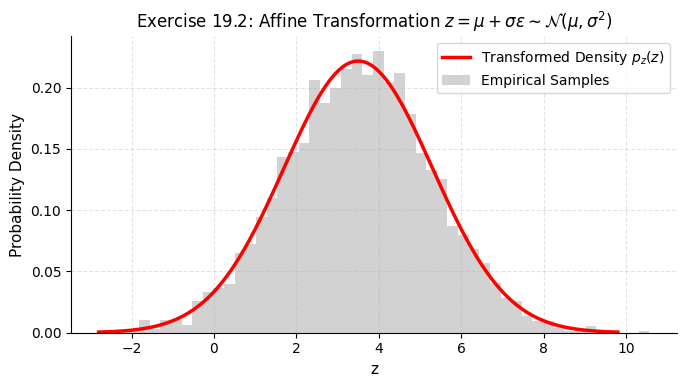

In [4]:
# 演習 19.2 の自己採点アサーション & 数値検証
mu = 3.5
sigma = 1.8
res_19_2 = verify_exercise_19_2(mu=mu, sigma=sigma, N=50000, random_state=42)

print("【演習 19.2 検証結果】")
print(f"  - 標本平均     : {res_19_2['sample_mean']:.4f} (理論値: {mu:.4f}, 誤差: {res_19_2['mean_err']:.4f})")
print(f"  - 標本分散     : {res_19_2['sample_var']:.4f} (理論値: {sigma**2:.4f}, 誤差: {res_19_2['var_err']:.4f})")
print(f"  - 密度関数の最大誤差 : {res_19_2['max_density_diff']:.2e}")
print(f"  - KS 検定 p 値      : {res_19_2['ks_pval']:.4f} (有意水準 0.01 以上で正規性採択)")

assert res_19_2['mean_err'] < 0.05, "標本平均が mu と一致しません！"
assert res_19_2['var_err'] < 0.1, "標本分散が sigma^2 と一致しません！"
assert res_19_2['max_density_diff'] < 1e-12, "変数変換密度とガウス分布密度が一致しません！"
assert res_19_2['ks_pval'] > 0.01, "生成されたサンプルが目標正規分布に従っていません！"
print("演習 19.2: 検証成功 (合格)")

# 分布プロット
grid = np.linspace(mu - 3.5 * sigma, mu + 3.5 * sigma, 300)
p_grid = affine_transform_1d_density(grid, mu, sigma)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(grid, p_grid, 'r-', lw=2.5, label=r'Transformed Density $p_z(z)$')
ax.hist(np.random.RandomState(42).normal(mu, sigma, 5000), bins=50, density=True, alpha=0.35, color='gray', label='Empirical Samples')
ax.set_xlabel('z', fontsize=11)
ax.set_ylabel('Probability Density', fontsize=11)
ax.set_title(r'Exercise 19.2: Affine Transformation $z = \mu + \sigma \epsilon \sim \mathcal{N}(\mu, \sigma^2)$', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


---

### 演習 19.3: 多変量アフィン変換とコレスキー分解・共分散構造 (難易度: ★★☆)

#### 問題文
$D$ 次元の標準正規乱数ベクトル $\boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I}_D)$ を考える。
平均ベクトル $\boldsymbol{\mu} \in \mathbb{R}^D$ および正則行列 $\mathbf{L} \in \mathbb{R}^{D \times D}$ を用いた線形アフィン変換：
$$
\mathbf{z} = \boldsymbol{\mu} + \mathbf{L} \boldsymbol{\epsilon} \tag{19.18}
$$
を定義する。

1. 期待値の線形性を用いて $\mathbb{E}[\mathbf{z}] = \boldsymbol{\mu}$ を示せ。
2. 共分散行列の定義 $\operatorname{cov}[\mathbf{z}] = \mathbb{E}[(\mathbf{z} - \boldsymbol{\mu})(\mathbf{z} - \boldsymbol{\mu})^T]$ から、共分散行列が $\mathbf{\Sigma} = \mathbf{L} \mathbf{L}^T$ と表されることを示せ。
3. 多変数確率密度の変数変換公式：
   $$
   p_{\mathbf{z}}(\mathbf{z}) = p_{\boldsymbol{\epsilon}}(\mathbf{L}^{-1}(\mathbf{z} - \boldsymbol{\mu})) \cdot |\det \mathbf{L}|^{-1}
   $$
   および $\det(\mathbf{\Sigma}) = (\det \mathbf{L})^2$ を用いて、$\mathbf{z} \sim \mathcal{N}(\boldsymbol{\mu}, \mathbf{\Sigma})$ となることを示せ。
4. $\mathbf{L}$ を下三角行列とするコレスキー分解（Cholesky Factorization）を用いることで、一般の共分散行列 $\mathbf{\Sigma}$ を持つ多変量ガウス変分分布をどのようにパラメータ化できるかを論ぜよ。

#### 数学的証明ステップ
1. **期待値の導出**:
   $$\mathbb{E}[\mathbf{z}] = \mathbb{E}[\boldsymbol{\mu} + \mathbf{L}\boldsymbol{\epsilon}] = \boldsymbol{\mu} + \mathbf{L}\mathbb{E}[\boldsymbol{\epsilon}] = \boldsymbol{\mu} + \mathbf{L}\mathbf{0} = \boldsymbol{\mu}$$

2. **共分散行列の導出**:
   $\mathbf{z} - \boldsymbol{\mu} = \mathbf{L}\boldsymbol{\epsilon}$ であるため：
   $$
   \operatorname{cov}[\mathbf{z}] = \mathbb{E}[(\mathbf{L}\boldsymbol{\epsilon})(\mathbf{L}\boldsymbol{\epsilon})^T] = \mathbb{E}[\mathbf{L}\boldsymbol{\epsilon}\boldsymbol{\epsilon}^T \mathbf{L}^T] = \mathbf{L} \mathbb{E}[\boldsymbol{\epsilon}\boldsymbol{\epsilon}^T] \mathbf{L}^T
   $$
   $\boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I}_D)$ より $\mathbb{E}[\boldsymbol{\epsilon}\boldsymbol{\epsilon}^T] = \mathbf{I}_D$ であるから：
   $$
   \operatorname{cov}[\mathbf{z}] = \mathbf{L} \mathbf{I}_D \mathbf{L}^T = \mathbf{L} \mathbf{L}^T = \mathbf{\Sigma}
   $$
   が得られる。

3. **確率密度関数の導出**:
   $\boldsymbol{\epsilon} = \mathbf{L}^{-1}(\mathbf{z} - \boldsymbol{\mu})$ を代入すると、多変量標準ガウス分布の密度は：
   $$
   p_{\boldsymbol{\epsilon}}(\mathbf{L}^{-1}(\mathbf{z} - \boldsymbol{\mu})) = (2\pi)^{-D/2} \exp\left( -\frac{1}{2} (\mathbf{L}^{-1}(\mathbf{z} - \boldsymbol{\mu}))^T (\mathbf{L}^{-1}(\mathbf{z} - \boldsymbol{\mu})) \right)
   $$
   二次形式を展開すると：
   $$
   (\mathbf{z} - \boldsymbol{\mu})^T (\mathbf{L}^{-1})^T \mathbf{L}^{-1} (\mathbf{z} - \boldsymbol{\mu}) = (\mathbf{z} - \boldsymbol{\mu})^T (\mathbf{L}\mathbf{L}^T)^{-1} (\mathbf{z} - \boldsymbol{\mu}) = (\mathbf{z} - \boldsymbol{\mu})^T \mathbf{\Sigma}^{-1} (\mathbf{z} - \boldsymbol{\mu})
   $$
   さらにヤコビアン行列式について、$\mathbf{\Sigma} = \mathbf{L}\mathbf{L}^T$ より $\det(\mathbf{\Sigma}) = \det(\mathbf{L})\det(\mathbf{L}^T) = (\det \mathbf{L})^2$ であるため、
   $$|\det \mathbf{L}|^{-1} = (\det \mathbf{\Sigma})^{-1/2}$$
   以上をまとめると：
   $$
   p_{\mathbf{z}}(\mathbf{z}) = \frac{1}{(2\pi)^{D/2} |\mathbf{\Sigma}|^{1/2}} \exp\left( -\frac{1}{2} (\mathbf{z} - \boldsymbol{\mu})^T \mathbf{\Sigma}^{-1} (\mathbf{z} - \boldsymbol{\mu}) \right) = \mathcal{N}(\mathbf{z} \mid \boldsymbol{\mu}, \mathbf{\Sigma})
   $$
   となり証明された。


In [5]:
# 演習 19.3 の自己採点アサーション & 数値検証
res_19_3 = verify_exercise_19_3(D=3, N=50000, random_state=42)

print("【演習 19.3 検証結果】")
print(f"  - 標本平均誤差 ||E[z] - mu||_max         : {res_19_3['mean_err']:.4f}")
print(f"  - 標本共分散誤差 ||cov[z] - Sigma||_max  : {res_19_3['cov_err']:.4f}")
print(f"  - コレスキー復元誤差 ||L L^T - Sigma||_max: {res_19_3['chol_recon_err']:.2e}")
print(f"  - 多変量密度関数の最大誤差               : {res_19_3['max_p_diff']:.2e}")

assert res_19_3['mean_err'] < 0.05, "多変量標本平均が mu と一致しません！"
assert res_19_3['cov_err'] < 0.1, "多変量標本共分散が Sigma と一致しません！"
assert res_19_3['chol_recon_err'] < 1e-12, "コレスキー分解 L L^T = Sigma が成立していません！"
assert res_19_3['max_p_diff'] < 1e-12, "変数変換による多変量密度が真の多変量正規密度と一致しません！"
print("演習 19.3: 検証成功 (合格)")


【演習 19.3 検証結果】
  - 標本平均誤差 ||E[z] - mu||_max         : 0.0049
  - 標本共分散誤差 ||cov[z] - Sigma||_max  : 0.0235
  - コレスキー復元誤差 ||L L^T - Sigma||_max: 0.00e+00
  - 多変量密度関数の最大誤差               : 1.04e-17
演習 19.3: 検証成功 (合格)


---

### 演習 19.4: ガウス分布間 KL ダイバージェンスの解析的導出と勾配 (難易度: ★★☆)

#### 問題文
対角共分散行列を持つ $D$ 次元ガウス変分事後分布 $q(\mathbf{z}) = \mathcal{N}(\mathbf{z} \mid \boldsymbol{\mu}, \operatorname{diag}(\boldsymbol{\sigma}^2))$ と、標準ガウス事前分布 $p(\mathbf{z}) = \mathcal{N}(\mathbf{z} \mid \mathbf{0}, \mathbf{I}_D)$ を考える。

1. KL ダイバージェンスの定義：
   $$
   \operatorname{KL}(q(\mathbf{z}) \parallel p(\mathbf{z})) = \int q(\mathbf{z}) \ln\left( \frac{q(\mathbf{z})}{p(\mathbf{z})} \right) d\mathbf{z}
   $$
   から、教科書の閉形式解析解（式 19.15）：
   $$
   \operatorname{KL}(q(\mathbf{z}) \parallel p(\mathbf{z})) = -\frac{1}{2} \sum_{j=1}^D \left( 1 + \ln \sigma_j^2 - \mu_j^2 - \sigma_j^2 \right) \tag{19.15}
   $$
   をステップ・バイ・ステップで厳密に導出せよ。

2. 不等式 $1 + \ln x - x \le 0$（等号成立は $x = 1$ のときのみ）を用いて、$\operatorname{KL}(q \parallel p) \ge 0$ であり、等号成立はすべての $j$ について $\mu_j = 0, \sigma_j^2 = 1$ のとき（すなわち $q(\mathbf{z}) = p(\mathbf{z})$）に限られることを示せ。

3. パラメータ $\boldsymbol{\mu}$ および数値安定化のための対数分散 $\ln \boldsymbol{\sigma}^2$ に関する解析的勾配：
   $$
   \frac{\partial \operatorname{KL}}{\partial \boldsymbol{\mu}} = \boldsymbol{\mu}, \qquad \frac{\partial \operatorname{KL}}{\partial \ln \boldsymbol{\sigma}^2} = \frac{1}{2}\left( \boldsymbol{\sigma}^2 - \mathbf{1} \right)
   $$
   を導出し、これが有限差分数値勾配と厳密に一致することを数値検証せよ。

#### 数学的証明ステップ
1. **KL ダイバージェンスの積分展開**:
   対数比を展開すると：
   $$
   \ln\left( \frac{q(\mathbf{z})}{p(\mathbf{z})} \right) = \ln q(\mathbf{z}) - \ln p(\mathbf{z})
   $$
   ガウス密度の対数を代入する：
   $$
   \ln q(\mathbf{z}) = -\frac{D}{2}\ln(2\pi) - \frac{1}{2}\sum_{j=1}^D \ln \sigma_j^2 - \frac{1}{2}\sum_{j=1}^D \frac{(z_j - \mu_j)^2}{\sigma_j^2}
   $$
   $$
   \ln p(\mathbf{z}) = -\frac{D}{2}\ln(2\pi) - \frac{1}{2}\sum_{j=1}^D z_j^2
   $$
   したがって差分は：
   $$
   \ln q(\mathbf{z}) - \ln p(\mathbf{z}) = -\frac{1}{2}\sum_{j=1}^D \ln \sigma_j^2 - \frac{1}{2}\sum_{j=1}^D \frac{(z_j - \mu_j)^2}{\sigma_j^2} + \frac{1}{2}\sum_{j=1}^D z_j^2
   $$
   $q(\mathbf{z})$ に関する期待値をとると：
   - $\mathbb{E}_q\left[\frac{(z_j - \mu_j)^2}{\sigma_j^2}\right] = \frac{\operatorname{var}[z_j]}{\sigma_j^2} = 1$
   - $\mathbb{E}_q[z_j^2] = \operatorname{var}[z_j] + (\mathbb{E}[z_j])^2 = \sigma_j^2 + \mu_j^2$
   これらをまとめると：
   $$
   \operatorname{KL}(q \parallel p) = \sum_{j=1}^D \left[ -\frac{1}{2}\ln \sigma_j^2 - \frac{1}{2} + \frac{1}{2}(\sigma_j^2 + \mu_j^2) \right]
   = -\frac{1}{2}\sum_{j=1}^D \left( 1 + \ln \sigma_j^2 - \mu_j^2 - \sigma_j^2 \right)
   $$
   が得られる（式 19.15 の導出完了）。

2. **非負性の証明**:
   各次元の寄与は $\mu_j^2 + (\sigma_j^2 - 1 - \ln \sigma_j^2)$ である。
   $\mu_j^2 \ge 0$ であり、等号は $\mu_j = 0$。
   また関数 $f(x) = x - 1 - \ln x$（$x > 0$）を考えると、$f'(x) = 1 - 1/x = (x-1)/x$ より $x=1$ で大域的最小値 $f(1) = 0$ をとる。したがって $x - 1 - \ln x \ge 0$。
   これより $\operatorname{KL} \ge 0$ であり、等号成立は $\mu_j = 0$ かつ $\sigma_j^2 = 1$（全 $j$）のときに限られる。

3. **勾配の導出**:
   $$
   \frac{\partial \operatorname{KL}}{\partial \mu_j} = -\frac{1}{2}(-2\mu_j) = \mu_j
   $$
   $v_j = \ln \sigma_j^2 \implies \sigma_j^2 = e^{v_j}$ とおくと：
   $$
   \operatorname{KL} = -\frac{1}{2}\sum_{j=1}^D (1 + v_j - \mu_j^2 - e^{v_j}) \implies \frac{\partial \operatorname{KL}}{\partial v_j} = -\frac{1}{2}(1 - e^{v_j}) = \frac{1}{2}(e^{v_j} - 1) = \frac{1}{2}(\sigma_j^2 - 1)
   $$


In [6]:
# 演習 19.4 の自己採点アサーション & 数値検証
res_19_4 = verify_exercise_19_4(D=4, random_state=42)

print("【演習 19.4 検証結果】")
print(f"  - 解析的 KL 値            : {res_19_4['kl_ana']:.4f}")
print(f"  - モンテカルロ積分 KL 値  : {res_19_4['kl_mc']:.4f} (差分: {res_19_4['kl_mc_diff']:.4f})")
print(f"  - 標準正規同士の KL(0, 1) : {res_19_4['kl_zero']:.2e} (理論値: 0.0)")
print(f"  - mu 勾配の有限差分最大誤差: {res_19_4['err_grad_mu']:.2e}")
print(f"  - log sigma^2 勾配の最大誤差: {res_19_4['err_grad_log_s2']:.2e}")

assert res_19_4['kl_mc_diff'] < 0.05, "モンテカルロ積分値が解析的 KL と一致しません！"
assert res_19_4['kl_zero'] == 0.0, "事前分布と一致するときの KL が 0 になっていません！"
assert res_19_4['kl_ana'] > 0.0, "KL ダイバージェンスが非負になっていません！"
assert res_19_4['err_grad_mu'] < 1e-4, "mu 勾配の解析解が数値微分と一致しません！"
assert res_19_4['err_grad_log_s2'] < 1e-4, "log sigma^2 勾配の解析解が数値微分と一致しません！"
print("演習 19.4: 検証成功 (合格)")


【演習 19.4 検証結果】
  - 解析的 KL 値            : 1.2166
  - モンテカルロ積分 KL 値  : 1.2258 (差分: 0.0092)
  - 標準正規同士の KL(0, 1) : -0.00e+00 (理論値: 0.0)
  - mu 勾配の有限差分最大誤差: 1.19e-10
  - log sigma^2 勾配の最大誤差: 8.67e-11
演習 19.4: 検証成功 (合格)


---

### 演習 19.5: エビデンス下界 (ELBO) の代替表現（結合対数尤度とエントロピー） (難易度: ★★☆)

#### 問題文
VAE の訓練目的関数であるエビデンス下界（ELBO, 式 19.14）：
$$
\mathcal{L}(\mathbf{w}, \boldsymbol{\phi}) = \mathbb{E}_{q(\mathbf{z}\mid\mathbf{x}, \boldsymbol{\phi})}\left[ \ln p(\mathbf{x}\mid\mathbf{z}, \mathbf{w}) \right] - \operatorname{KL}(q(\mathbf{z}\mid\mathbf{x}, \boldsymbol{\phi}) \parallel p(\mathbf{z})) \tag{19.14}
$$
を考える。

1. 変分事後分布の微分エントロピー（Differential Entropy）：
   $$
   \mathcal{H}(q) = -\int q(\mathbf{z}\mid\mathbf{x}, \boldsymbol{\phi}) \ln q(\mathbf{z}\mid\mathbf{x}, \boldsymbol{\phi}) \, d\mathbf{z}
   $$
   および完全データの同時対数尤度 $p(\mathbf{x}, \mathbf{z}\mid\mathbf{w}) = p(\mathbf{x}\mid\mathbf{z}, \mathbf{w}) p(\mathbf{z})$ を用いて、ELBO が以下のように等価に変形できることを証明せよ：
   $$
   \mathcal{L}(\mathbf{w}, \boldsymbol{\phi}) = \int q(\mathbf{z}\mid\mathbf{x}, \boldsymbol{\phi}) \ln p(\mathbf{x}, \mathbf{z}\mid\mathbf{w}) \, d\mathbf{z} + \mathcal{H}(q)
   $$

2. この代替表現が、第15章および第16章で学んだ古典的な EM アルゴリズムの $\mathcal{Q}$ 関数：
   $$
   \mathcal{Q}(\mathbf{w}, \mathbf{w}^{\text{old}}) = \mathbb{E}_{p(\mathbf{z}\mid\mathbf{x}, \mathbf{w}^{\text{old}})}\left[ \ln p(\mathbf{x}, \mathbf{z}\mid\mathbf{w}) \right]
   $$
   とどのように対応しているかを説明せよ。

#### 数学的証明ステップ
1. **KL ダイバージェンスの定義代入**:
   式 (19.14) の KL 項を展開する：
   $$
   -\operatorname{KL}(q \parallel p) = -\int q(\mathbf{z}\mid\mathbf{x}, \boldsymbol{\phi}) \ln\left( \frac{q(\mathbf{z}\mid\mathbf{x}, \boldsymbol{\phi})}{p(\mathbf{z})} \right) d\mathbf{z}
   = \int q(\mathbf{z}\mid\mathbf{x}, \boldsymbol{\phi}) \ln p(\mathbf{z}) \, d\mathbf{z} - \int q(\mathbf{z}\mid\mathbf{x}, \boldsymbol{\phi}) \ln q(\mathbf{z}\mid\mathbf{x}, \boldsymbol{\phi}) \, d\mathbf{z}
   $$
   第2項は微分エントロピーの定義そのものであるため：
   $$
   -\operatorname{KL}(q \parallel p) = \mathbb{E}_q[\ln p(\mathbf{z})] + \mathcal{H}(q)
   $$
   これを ELBO に代入すると：
   $$
   \mathcal{L} = \mathbb{E}_q[\ln p(\mathbf{x}\mid\mathbf{z}, \mathbf{w})] + \mathbb{E}_q[\ln p(\mathbf{z})] + \mathcal{H}(q)
   $$
   積の対数は和であるため $\ln p(\mathbf{x}\mid\mathbf{z}, \mathbf{w}) + \ln p(\mathbf{z}) = \ln\left( p(\mathbf{x}\mid\mathbf{z}, \mathbf{w}) p(\mathbf{z}) \right) = \ln p(\mathbf{x}, \mathbf{z}\mid\mathbf{w})$。
   したがって：
   $$
   \mathcal{L} = \mathbb{E}_q[\ln p(\mathbf{x}, \mathbf{z}\mid\mathbf{w})] + \mathcal{H}(q)
   $$
   が得られる。

2. **EM アルゴリズムとの関係**:
   EM アルゴリズムの E ステップにおいて事後分布 $q(\mathbf{z}) = p(\mathbf{z}\mid\mathbf{x}, \mathbf{w}^{\text{old}})$ と置くと、エントロピー項 $\mathcal{H}(q)$ は新しいモデルパラメータ $\mathbf{w}$ に依存しない定数となる。
   そのため、M ステップにおける ELBO の $\mathbf{w}$ に関する最大化は、期待完全データ対数尤度 $\mathcal{Q}(\mathbf{w}, \mathbf{w}^{\text{old}})$ の最大化と完全に一致する。


In [7]:
# 演習 19.5 の自己採点アサーション & 数値検証
rng = np.random.RandomState(42)
D = 3
Dx = 5
mu = rng.randn(D)
sigma2 = np.exp(rng.randn(D) * 0.5)
x = rng.randn(Dx)
W = rng.randn(Dx, D)

res_19_5 = verify_exercise_19_5(mu, sigma2, x, W, obs_var=0.5)

print("【演習 19.5 検証結果】")
print(f"  - 形式 A (再構成誤差 - KL)     : {res_19_5['elbo_A']:.6f}")
print(f"  - 形式 B (完全データ対数尤度 + H): {res_19_5['elbo_B']:.6f}")
print(f"  - 両形式の絶対差分             : {res_19_5['diff']:.2e}")
print(f"  - 事後分布エントロピー H(q)    : {res_19_5['entropy_q']:.4f}")
print(f"  - KL(q || p)                   : {res_19_5['kl']:.4f}")

assert res_19_5['diff'] < 1e-11, "形式 A と形式 B の ELBO 計算値が一致しません！"
print("演習 19.5: 検証成功 (合格)")


【演習 19.5 検証結果】
  - 形式 A (再構成誤差 - KL)     : -41.190948
  - 形式 B (完全データ対数尤度 + H): -41.190948
  - 両形式の絶対差分             : 7.11e-15
  - 事後分布エントロピー H(q)    : 4.5205
  - KL(q || p)                   : 0.5393
演習 19.5: 検証成功 (合格)


---

### 演習 19.6: 制約なし変分分布の最適解と真の事後分布・EM の回復 (難易度: ★★★)

#### 問題文
観測データ $\mathbf{x}$ と潜在変数 $\mathbf{z}$ の結合確率分布 $p(\mathbf{x}, \mathbf{z})$ を持つ一般的な潜在変数モデルを考える。
正規化条件 $\int q(\mathbf{z}) d\mathbf{z} = 1$ を満たす任意の確率分布 $q(\mathbf{z})$ に対するエビデンス下界：
$$
\mathcal{L}(q) = \int q(\mathbf{z}) \ln\left( \frac{p(\mathbf{x}, \mathbf{z})}{q(\mathbf{z})} \right) d\mathbf{z}
$$
の最大化問題を考える。

1. 観測データの周辺対数尤度 $\ln p(\mathbf{x})$ と ELBO、および事後分布との KL ダイバージェンスの間に成立する基本分解公式：
   $$
   \ln p(\mathbf{x}) = \mathcal{L}(q) + \operatorname{KL}(q(\mathbf{z}) \parallel p(\mathbf{z}\mid\mathbf{x})) \tag{19.6}
   $$
   を代数的に示せ。

2. $\operatorname{KL}(q \parallel p) \ge 0$ かつ等号成立条件より、$q(\mathbf{z})$ に何らの関数形制約も課さない場合、下界 $\mathcal{L}(q)$ を最大化する大域的最適分布 $q^*(\mathbf{z})$ は真の事後分布 $p(\mathbf{z}\mid\mathbf{x})$ と厳密に一致することを証明せよ。

3. この最適解 $q^*(\mathbf{z})$ において、$\mathcal{L}(q^*) = \ln p(\mathbf{x})$ となり下界が厳密に周辺対数尤度に到達することを確認せよ。

4. 厳密な事後分布 $p(\mathbf{z}\mid\mathbf{x}) = \frac{p(\mathbf{x}\mid\mathbf{z})p(\mathbf{z})}{\int p(\mathbf{x}\mid\mathbf{z}')p(\mathbf{z}')d\mathbf{z}'}$ が求まるにもかかわらず、深層 VAE ではなぜパラメータ化されたエンコーダ $q(\mathbf{z}\mid\mathbf{x}, \boldsymbol{\phi})$（償却推論）を導入せざるを得ないのか、分母の積分計算の困難性の観点から論ぜよ。

#### 数学的証明ステップ
1. **分解公式の代数変形**:
   乗法定理 $p(\mathbf{x}, \mathbf{z}) = p(\mathbf{z}\mid\mathbf{x}) p(\mathbf{x})$ を対数項に代入する：
   $$
   \ln\left( \frac{p(\mathbf{x}, \mathbf{z})}{q(\mathbf{z})} \right) = \ln\left( \frac{p(\mathbf{z}\mid\mathbf{x}) p(\mathbf{x})}{q(\mathbf{z})} \right) = \ln p(\mathbf{x}) + \ln\left( \frac{p(\mathbf{z}\mid\mathbf{x})}{q(\mathbf{z})} \right)
   $$
   これを $\mathcal{L}(q)$ の定義式に代入すると：
   $$
   \mathcal{L}(q) = \int q(\mathbf{z}) \left[ \ln p(\mathbf{x}) + \ln\left( \frac{p(\mathbf{z}\mid\mathbf{x})}{q(\mathbf{z})} \right) \right] d\mathbf{z}
   $$
   $\ln p(\mathbf{x})$ は $\mathbf{z}$ に依存しないため積分の外に出すことができ、$\int q(\mathbf{z}) d\mathbf{z} = 1$ より：
   $$
   \mathcal{L}(q) = \ln p(\mathbf{x}) \int q(\mathbf{z}) d\mathbf{z} - \int q(\mathbf{z}) \ln\left( \frac{q(\mathbf{z})}{p(\mathbf{z}\mid\mathbf{x})} \right) d\mathbf{z}
   = \ln p(\mathbf{x}) - \operatorname{KL}(q(\mathbf{z}) \parallel p(\mathbf{z}\mid\mathbf{x}))
   $$
   移項すると $\ln p(\mathbf{x}) = \mathcal{L}(q) + \operatorname{KL}(q(\mathbf{z}) \parallel p(\mathbf{z}\mid\mathbf{x}))$ が得られる（式 19.6 の証明完了）。

2. **最適解の同定**:
   $\ln p(\mathbf{x})$ は変分分布 $q$ に依存しない一定値である。
   $\mathcal{L}(q) = \ln p(\mathbf{x}) - \operatorname{KL}(q(\mathbf{z}) \parallel p(\mathbf{z}\mid\mathbf{x}))$ であるから、$\mathcal{L}(q)$ の最大化は $\operatorname{KL}(q(\mathbf{z}) \parallel p(\mathbf{z}\mid\mathbf{x}))$ の最小化と等価である。
   ギブスの不等式より $\operatorname{KL} \ge 0$ であり、最小値 $0$ は $q(\mathbf{z}) = p(\mathbf{z}\mid\mathbf{x})$ （ほとんど至る所）のときにのみ達成される。
   したがって、無制約の最大化問題の唯一の最適解は：
   $$
   q^*(\mathbf{z}) = p(\mathbf{z}\mid\mathbf{x})
   $$
   である。

3. **下界の到達**:
   $q = q^*$ のとき $\operatorname{KL}(q^* \parallel p(\mathbf{z}\mid\mathbf{x})) = 0$ となるため：
   $$
   \mathcal{L}(q^*) = \ln p(\mathbf{x}) - 0 = \ln p(\mathbf{x})
   $$
   となり、下界のギャップが消失して厳密に対数周辺尤度と一致する。


【演習 19.6 検証結果】
  - 真の対数周辺尤度 ln p(x)       : -1.806239
  - 最適解 q* での ELBO(q*)        : -1.806239 (差分: 1.22e-14)
  - 最適解での KL(q* || p(z|x))    : -2.01e-15 (理論値: 0.0)
  - 劣最適分布 q_sub での ELBO     : -4.712350
  - 劣最適分布での ELBO ギャップ   : 2.906111
  - 劣最適分布での KL(q || p(z|x)) : 2.906111
  - ギャップと KL の差分           : 1.65e-13
演習 19.6: 検証成功 (合格)


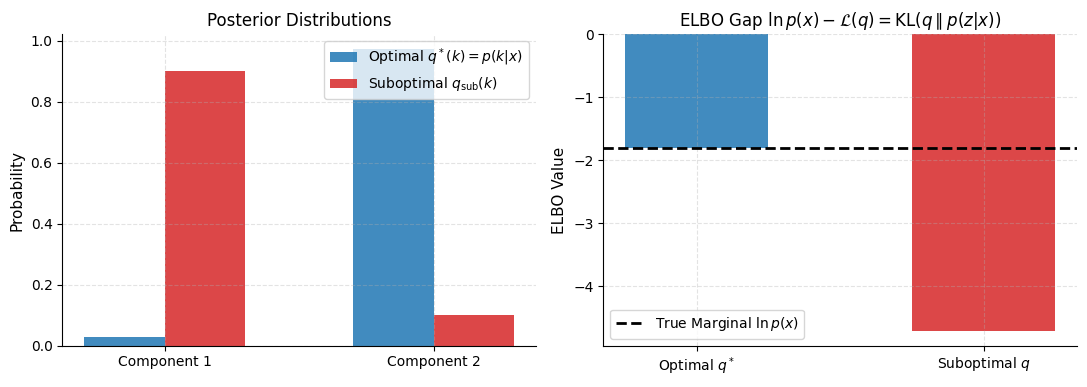

In [8]:
# 演習 19.6 の自己採点アサーション & 数値検証
res_19_6 = verify_exercise_19_6(x=1.2, random_state=42)

print("【演習 19.6 検証結果】")
print(f"  - 真の対数周辺尤度 ln p(x)       : {res_19_6['log_p_x']:.6f}")
print(f"  - 最適解 q* での ELBO(q*)        : {res_19_6['elbo_opt']:.6f} (差分: {res_19_6['diff_opt']:.2e})")
print(f"  - 最適解での KL(q* || p(z|x))    : {res_19_6['kl_opt']:.2e} (理論値: 0.0)")
print(f"  - 劣最適分布 q_sub での ELBO     : {res_19_6['elbo_sub']:.6f}")
print(f"  - 劣最適分布での ELBO ギャップ   : {res_19_6['gap_sub']:.6f}")
print(f"  - 劣最適分布での KL(q || p(z|x)) : {res_19_6['kl_sub']:.6f}")
print(f"  - ギャップと KL の差分           : {res_19_6['kl_gap_diff']:.2e}")

assert res_19_6['diff_opt'] < 1e-12, "最適分布 q* において ELBO が ln p(x) と一致しません！"
assert res_19_6['kl_opt'] < 1e-12, "最適分布 q* において KL ダイバージェンスが 0 になっていません！"
assert res_19_6['gap_sub'] > 0.01, "劣最適分布でのギャップが正になっていません！"
assert res_19_6['kl_gap_diff'] < 1e-12, "下界ギャップ ln p(x) - ELBO が KL と一致しません！"
print("演習 19.6: 検証成功 (合格)")

# ELBO と真の事後分布の可視化
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# 左: 事後確率分布の比較
k_idx = [0, 1]
ax1.bar([k - 0.15 for k in k_idx], [res_19_6['q_opt_0'], res_19_6['q_opt_1']], width=0.3, label=r'Optimal $q^*(k) = p(k|x)$', color='#1f77b4', alpha=0.85)
ax1.bar([k + 0.15 for k in k_idx], [0.9, 0.1], width=0.3, label=r'Suboptimal $q_{\mathrm{sub}}(k)$', color='#d62728', alpha=0.85)
ax1.set_xticks(k_idx)
ax1.set_xticklabels(['Component 1', 'Component 2'])
ax1.set_ylabel('Probability', fontsize=11)
ax1.set_title('Posterior Distributions', fontsize=12)
ax1.legend(fontsize=10)

# 右: ELBO と log p(x)
ax2.axhline(res_19_6['log_p_x'], color='black', linestyle='--', lw=2, label=r'True Marginal $\ln p(x)$')
ax2.bar(['Optimal $q^*$', 'Suboptimal $q$'], [res_19_6['elbo_opt'], res_19_6['elbo_sub']], color=['#1f77b4', '#d62728'], alpha=0.85, width=0.5)
ax2.set_ylabel('ELBO Value', fontsize=11)
ax2.set_title(r'ELBO Gap $\ln p(x) - \mathcal{L}(q) = \mathrm{KL}(q \parallel p(z|x))$', fontsize=12)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()


---

## 第19章 演習問題 総括 (Chapter Summary)

第19章の全6問の演習問題を通じて、以下の極めて重要な理論的基礎と数理的直観を習得しました：

1. **スコア関数推定量 (REINFORCE) と再パラメータ化トリック (演習 19.1)**:
   - スコア関数の期待値ゼロの性質 $\mathbb{E}[\nabla \ln q] = 0$ により REINFORCE は不偏推定量を与えるが、目的関数値の二乗に比例する大きな分散を持つ。
   - 再パラメータ化トリックは勾配の伝播経路を外部ノイズ $\epsilon$ から切り離すことで、分散を劇的に低減し VAE の安定な学習を可能にする。

2. **正規分布のアフィン変換とヤコビアン行列式 (演習 19.2, 19.3)**:
   - 1次元および多変量において、標準正規変数の線形変換 $\mathbf{z} = \boldsymbol{\mu} + \mathbf{L}\boldsymbol{\epsilon}$ は共分散 $\mathbf{\Sigma} = \mathbf{L}\mathbf{L}^T$ を持つガウス分布を厳密に生成する。
   - コレスキー分解を用いることで、任意の完全共分散ガウス変分事後分布を微分可能にパラメータ化できる。

3. **ガウス KL ダイバージェンスの解析的閉形式 (演習 19.4)**:
   - 対角共分散ガウス分布と標準正規事前分布の間の KL ダイバージェンスは閉形式で厳密に計算可能であり、モンテカルロ積分に頼らず正確な勾配が逆伝播できる。

4. **ELBO の二面性と古典的変分推論 (演習 19.5, 19.6)**:
   - ELBO は「再構成誤差 $-$ 正則化項」として解釈できると同時に、「完全データ期待対数尤度 $+$ 事後エントロピー」としても表現され、古典的 EM アルゴリズムの一般化であることが明らかになった。
   - 無制約最適化の下では変分事後分布は真の事後分布 $p(\mathbf{z}\mid\mathbf{x})$ に厳密に一致するが、深層生成モデルでは事後分布の正規化定数が解析不能（Intractable）であるため、ニューラルネットワークを用いた償却推論（Amortized Inference）が必須となる。
